# 3. CSP implementation

## 1. import settings

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Path settings
import sys
sys.path.append('..')

# import basic lib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import scikit learn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy.linalg import eigh

# import mne
import mne

from src.preprocessing import preprocess_eeg_data, preprocess_subject_runs
from src.evaluation import evaluate_cross_validation_baseline
from src.csp import CSP
from src.pipeline import create_pipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1-1. initialization

In [4]:
np.random.seed(42)
sns.set_theme(style='whitegrid', context='notebook')

X, y = preprocess_eeg_data(subject_id=1, run_id=3)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Extracting EDF parameters from /home/donghank/total-perspective-vortex/notebook/../physionet.org/files/eegmmidb/1.0.0/S001/S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activate

## 2. CSP implementation

### 2-1 Testing

In [5]:
csp = CSP(n_components=4)

csp.fit(X, y)
features = csp.transform(X)

print(f"features shape: {features.shape}")
print(f"features:\n{features}")

AttributeError: 'CSP' object has no attribute 'reg'

NameError: name 'features' is not defined

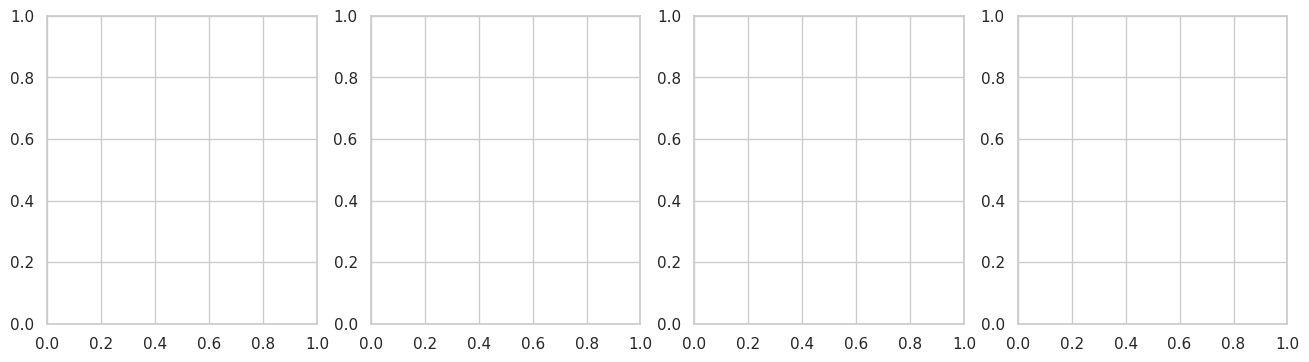

In [6]:
# visualization

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i in range(4):
	axes[i].scatter(features[y == 0, i], np.zeros(sum(y == 0)),
						label='Left (T1)', s=100, alpha=0.7)
	axes[i].scatter(features[y == 1, i], np.ones(sum(y == 1)),
						label='Right (T2)', s=100, alpha=0.7)
	axes[i].set_title(f'Filter {i}')
	axes[i].set_xlabel('Log variance')
	axes[i].set_yticks([0, 1], ['Left', 'Right'])
	axes[i].legend()

plt.tight_layout()
plt.show()

In [8]:
mne.set_log_level('WARNING')

raw_temp = mne.io.read_raw_edf(
	'../physionet.org/files/eegmmidb/1.0.0/S001/S001R03.edf',
	preload=False
)
print([f"{i}: {ch}" for i, ch in enumerate(raw_temp.ch_names)])

ch_names = raw_temp.ch_names

c3_index = ch_names.index('C3..')
c4_index = ch_names.index('C4..')

print(f"C3 index: {c3_index}")
print(f"C4 index: {c4_index}")

['0: Fc5.', '1: Fc3.', '2: Fc1.', '3: Fcz.', '4: Fc2.', '5: Fc4.', '6: Fc6.', '7: C5..', '8: C3..', '9: C1..', '10: Cz..', '11: C2..', '12: C4..', '13: C6..', '14: Cp5.', '15: Cp3.', '16: Cp1.', '17: Cpz.', '18: Cp2.', '19: Cp4.', '20: Cp6.', '21: Fp1.', '22: Fpz.', '23: Fp2.', '24: Af7.', '25: Af3.', '26: Afz.', '27: Af4.', '28: Af8.', '29: F7..', '30: F5..', '31: F3..', '32: F1..', '33: Fz..', '34: F2..', '35: F4..', '36: F6..', '37: F8..', '38: Ft7.', '39: Ft8.', '40: T7..', '41: T8..', '42: T9..', '43: T10.', '44: Tp7.', '45: Tp8.', '46: P7..', '47: P5..', '48: P3..', '49: P1..', '50: Pz..', '51: P2..', '52: P4..', '53: P6..', '54: P8..', '55: Po7.', '56: Po3.', '57: Poz.', '58: Po4.', '59: Po8.', '60: O1..', '61: Oz..', '62: O2..', '63: Iz..']
C3 index: 8
C4 index: 12


## 3. CSP + LDA Pipeline Baseline Evaluation

This section evaluates the current pipeline using epoch-level cross-validation
on runs R03, R07 and R11.

This result is a baseline experiment and is not the final held-out run test evaluation.

In [10]:
# set the pipeline
pipeline = create_pipeline()

results_test = evaluate_cross_validation_baseline(
	pipeline=pipeline,
	run_ids=[3, 7, 11],
	subject_range=range(1, 110)
)


Subject 1: mean accuracy = 0.556
Subject 2: mean accuracy = 0.689
Subject 3: mean accuracy = 0.622
Subject 4: mean accuracy = 0.800
Subject 5: mean accuracy = 0.556
Subject 6: mean accuracy = 0.489
Subject 7: mean accuracy = 1.000
Subject 8: mean accuracy = 0.689
Subject 9: mean accuracy = 0.578
Subject 10: mean accuracy = 0.756
Subject 11: mean accuracy = 0.600
Subject 12: mean accuracy = 0.689
Subject 13: mean accuracy = 0.733
Subject 14: mean accuracy = 0.689
Subject 15: mean accuracy = 0.689
Subject 16: mean accuracy = 0.778
Subject 17: mean accuracy = 0.511
Subject 18: mean accuracy = 0.444
Subject 19: mean accuracy = 0.889
Subject 20: mean accuracy = 0.444
Subject 21: mean accuracy = 0.733
Subject 22: mean accuracy = 0.822
Subject 23: mean accuracy = 0.556
Subject 24: mean accuracy = 0.711
Subject 25: mean accuracy = 0.733
Subject 26: mean accuracy = 0.867
Subject 27: mean accuracy = 0.511
Subject 28: mean accuracy = 0.533
Subject 29: mean accuracy = 0.756
Subject 30: mean accura

/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:42: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  return mne.io.read_raw_edf(edf_path, preload=True)
/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:42: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  return mne.io.read_raw_edf(edf_path, preload=True)


### Testing for the bonus
    - Tikhonov-style dignoal loading strength for CSP covariance regularization

In [12]:
print("Test results for bonus 1 (CSP regularization):")
pipeline_bonus1 = create_pipeline(csp_reg=0.1)
results_test_bonus1 = evaluate_cross_validation_baseline(
    pipeline=pipeline_bonus1,
    run_ids=[3, 7, 11],
    subject_range=range(1, 110)
)

print("Test results for bonus 2 (CSP regularization with higher strength):")
pipeline_bonus2 = create_pipeline(csp_reg=0.5)
results_test_bonus2 = evaluate_cross_validation_baseline(
    pipeline=pipeline_bonus2,
    run_ids=[3, 7, 11],
    subject_range=range(1, 110)
)


print("Test results for bonus 3 (CSP regularization with lower strength):")
pipeline_bonus3 = create_pipeline(csp_reg=0.01)
results_test_bonus3 = evaluate_cross_validation_baseline(
    pipeline=pipeline_bonus3,
    run_ids=[3, 7, 11],
    subject_range=range(1, 110)
)

Test results for bonus 1 (CSP regularization):
Subject 1: mean accuracy = 0.644
Subject 2: mean accuracy = 0.511
Subject 3: mean accuracy = 0.578
Subject 4: mean accuracy = 0.756
Subject 5: mean accuracy = 0.556
Subject 6: mean accuracy = 0.489
Subject 7: mean accuracy = 0.933
Subject 8: mean accuracy = 0.644
Subject 9: mean accuracy = 0.378
Subject 10: mean accuracy = 0.756
Subject 11: mean accuracy = 0.778
Subject 12: mean accuracy = 0.689
Subject 13: mean accuracy = 0.667
Subject 14: mean accuracy = 0.667
Subject 15: mean accuracy = 0.578
Subject 16: mean accuracy = 0.511
Subject 17: mean accuracy = 0.511
Subject 18: mean accuracy = 0.489
Subject 19: mean accuracy = 0.756
Subject 20: mean accuracy = 0.578
Subject 21: mean accuracy = 0.578
Subject 22: mean accuracy = 0.844
Subject 23: mean accuracy = 0.556
Subject 24: mean accuracy = 0.622
Subject 25: mean accuracy = 0.689
Subject 26: mean accuracy = 0.800
Subject 27: mean accuracy = 0.422
Subject 28: mean accuracy = 0.578
Subject 29

/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:42: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  return mne.io.read_raw_edf(edf_path, preload=True)
/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:42: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  return mne.io.read_raw_edf(edf_path, preload=True)


Subject 88: ERROR EDF file not found: /home/donghank/total-perspective-vortex/notebook/../physionet.org/files/eegmmidb/1.0.0/S088/S088R11.edf
Download the dataset before running code
Subject 89: ERROR EDF file not found: /home/donghank/total-perspective-vortex/notebook/../physionet.org/files/eegmmidb/1.0.0/S089/S089R03.edf
Download the dataset before running code
Subject 90: ERROR EDF file not found: /home/donghank/total-perspective-vortex/notebook/../physionet.org/files/eegmmidb/1.0.0/S090/S090R03.edf
Download the dataset before running code
Subject 91: ERROR EDF file not found: /home/donghank/total-perspective-vortex/notebook/../physionet.org/files/eegmmidb/1.0.0/S091/S091R03.edf
Download the dataset before running code
Subject 92: ERROR EDF file not found: /home/donghank/total-perspective-vortex/notebook/../physionet.org/files/eegmmidb/1.0.0/S092/S092R03.edf
Download the dataset before running code
Subject 93: ERROR EDF file not found: /home/donghank/total-perspective-vortex/noteboo

/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:42: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  return mne.io.read_raw_edf(edf_path, preload=True)
/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:42: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  return mne.io.read_raw_edf(edf_path, preload=True)


Subject 88: ERROR EDF file not found: /home/donghank/total-perspective-vortex/notebook/../physionet.org/files/eegmmidb/1.0.0/S088/S088R11.edf
Download the dataset before running code
Subject 89: ERROR EDF file not found: /home/donghank/total-perspective-vortex/notebook/../physionet.org/files/eegmmidb/1.0.0/S089/S089R03.edf
Download the dataset before running code
Subject 90: ERROR EDF file not found: /home/donghank/total-perspective-vortex/notebook/../physionet.org/files/eegmmidb/1.0.0/S090/S090R03.edf
Download the dataset before running code
Subject 91: ERROR EDF file not found: /home/donghank/total-perspective-vortex/notebook/../physionet.org/files/eegmmidb/1.0.0/S091/S091R03.edf
Download the dataset before running code
Subject 92: ERROR EDF file not found: /home/donghank/total-perspective-vortex/notebook/../physionet.org/files/eegmmidb/1.0.0/S092/S092R03.edf
Download the dataset before running code
Subject 93: ERROR EDF file not found: /home/donghank/total-perspective-vortex/noteboo

/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:42: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  return mne.io.read_raw_edf(edf_path, preload=True)
/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:42: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  return mne.io.read_raw_edf(edf_path, preload=True)
